# Week 8: Tree-based Models (Credit Approval - UCI)- Instructor notebook

> ```
> -In this notebook, you will walk through a standard machine-learning workflow for Tree-based models on the UCI Credit Approval dataset.
> -Why does this matter?
>     1. Tree-based models are widely used in many Machine Learning projects, and you should be familiar with the entire process.
>     2. Getting comfortable with these learning algorithms will facilitate your understanding of the more complex ones.
> ```

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, brier_score_loss)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['figure.dpi'] = 120

# Reproducibility
np.random.seed(42)

## 1. Load & Inspect

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# Fetch dataset 
credit_approval = fetch_ucirepo(id=27) 


# Data (as pandas dataframes) 
X = credit_approval.data.features 
y = credit_approval.data.targets 
  
# Build dataframe
df_credit = pd.concat([y,X],axis=1)

display(df_credit.head())
df_credit.info()
print("\nRelevant numeric variables statistics:\n", df_credit.select_dtypes(exclude=object).describe())
print("Missing values per column:\n", df_credit.isna().sum())
print("\nCorrelation matrix ('A15','A14','A11','A8','A3','A2'):\n", 
      df_credit[['A15','A14','A11','A8','A3','A2']].corr())
print("\nTarget distribution:")
print(df_credit["A16"].value_counts(dropna=False))

,A16,A15,A14,A13,A12,A11,A10,A9,A8,A7,A6,A5,A4,A3,A2,A1
0,+,0,202.0,g,f,1,t,t,1.25,v,w,g,u,0.000,30.83,b
1,+,560,43.0,g,f,6,t,t,3.04,h,q,g,u,4.460,58.67,a
2,+,824,280.0,g,f,0,f,t,1.50,h,q,g,u,0.500,24.50,a
3,+,3,100.0,g,t,5,t,t,3.75,v,w,g,u,1.540,27.83,b
4,+,0,120.0,s,f,0,f,t,1.71,v,w,g,u,5.625,20.17,b


<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A16     690 non-null    str    
 1   A15     690 non-null    int64  
 2   A14     677 non-null    float64
 3   A13     690 non-null    str    
 4   A12     690 non-null    str    
 5   A11     690 non-null    int64  
 6   A10     690 non-null    str    
 7   A9      690 non-null    str    
 8   A8      690 non-null    float64
 9   A7      681 non-null    str    
 10  A6      681 non-null    str    
 11  A5      684 non-null    str    
 12  A4      684 non-null    str    
 13  A3      690 non-null    float64
 14  A2      678 non-null    float64
 15  A1      678 non-null    str    
dtypes: float64(4), int64(2), str(10)
memory usage: 93.8 KB

Relevant numeric variables statistics:
                  A15          A14        A11          A8          A3  \
count     690.000000   677.000000  690.00000  690.000000  690.00000

> 🧩 **Think About It**  
> - Is the target class balanced? How might that affect evaluation (e.g., accuracy vs AUC vs Average Precision)?

## 2. Preprocessing Pipeline
1. Convert target to binary: `A16` (`+` → 1, `-` → 0)
2. Prepare y & X
3. Split with **stratification** to keep class balance (ensures both train and test datasets preserve the same positive/negative ratio).
4. Identify categorical vs. numeric columns & create preprocessing pipeline.

We'll use a `ColumnTransformer` to **impute** (mean/most_frequent) and **OneHotEncode** categoricals.


In [3]:
# 1. Convert target to binary
df = df_credit.copy()
df['y'] = df["A16"].map({"+": 1, "-": 0})

display(df[['y']].describe())  # 44% of credit approval +> Dataset is slightly imbalanced.
print("\nCorrelation matrix ('y','A15','A14','A11','A8','A3','A2'):\n", 
      df[['y','A15','A14','A11','A8','A3','A2']].corr())

,y
count,690.000000
mean,0.444928
std,0.497318
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000



Correlation matrix ('y','A15','A14','A11','A8','A3','A2'):
             y       A15       A14       A11        A8        A3        A2
y    1.000000  0.175657 -0.100935  0.406410  0.322475  0.206294  0.162881
A15  0.175657  1.000000  0.066853  0.063692  0.051345  0.123121  0.018553
A14 -0.100935  0.066853  1.000000 -0.120096 -0.077163 -0.224242 -0.079812
A11  0.406410  0.063692 -0.120096  1.000000  0.322330  0.271207  0.185912
A8   0.322475  0.051345 -0.077163  0.322330  1.000000  0.298902  0.395751
A3   0.206294  0.123121 -0.224242  0.271207  0.298902  1.000000  0.202317
A2   0.162881  0.018553 -0.079812  0.185912  0.395751  0.202317  1.000000


In [4]:
# 2. Prepare y & X
y = df['y']
X = df.drop(columns=["A16", 'y'], errors='ignore')

In [5]:
# 3. Train/test split (hold-out)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train positive rate:", y_train.mean(), " Test positive rate:", y_test.mean())

Train: (552, 15)  Test: (138, 15)
Train positive rate: 0.44565217391304346  Test positive rate: 0.4420289855072464


In [6]:
# 4. Separate dtypes for preprocessing steps
num_feats = ["A2","A3","A8","A11","A14","A15"]
cat_feats = [c for c in X.columns if c not in num_feats]

# Preprocessing steps
# Categorical transformer
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Numerical transformer (no scaling)
num_transformer_no_scaling = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

# Numerical transformer (with scaling)
num_transformer_with_scaling = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Preprocessing pipelines (one without scaling, one with scaling)
preprocessor_no_scaling = ColumnTransformer(transformers=[
    ("num", num_transformer_no_scaling, num_feats),
    ("cat", cat_transformer, cat_feats)
])

preprocessor_with_scaling = ColumnTransformer(transformers=[
    ("num", num_transformer_with_scaling, num_feats),
    ("cat", cat_transformer, cat_feats)
])

print("Numerical:", num_feats)
print("Categorical:", cat_feats)

Numerical: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
Categorical: ['A13', 'A12', 'A10', 'A9', 'A7', 'A6', 'A5', 'A4', 'A1']



## 3. Helper: Quick Evaluation

We’ll print **Accuracy**, **Confusion Matrix**, **Classification Report**, and **ROC–AUC** (with ROC curve).


In [7]:
def evaluate_classifier(name, fitted_pipeline, X_train, y_train, X_test, y_test):
    """Evaluate a fitted pipeline with standard metrics and an ROC curve."""
    print(f"\n=== {name} ===")
    y_pred = fitted_pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=3))
    try:
        y_proba = fitted_pipeline.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        print(f"ROC–AUC: {auc:.4f}")
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure()
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
        plt.plot([0,1],[0,1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
    except Exception as e:
        print("predict_proba not available or failed:", e)


## 4. Baseline Models (Decision Tree, Random Forest, XGBoost)

We start with **default-ish** settings to set a baseline.


### 🎯 Tuning Priority Matrix — Decision Tree, Random Forest, and XGBoost

| **Hyperparameter** | 🌳 **Decision Tree** | 🌲 **Random Forest** | ⚡ **XGBoost** | **Typical Range / Starting Point** | **Impact / Why It Matters** |
|:--------------------|:------------------:|:------------------:|:--------------:|:----------------------------------|:-----------------------------|
| `max_depth` | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | 3–30 *(or None)* | Main control of model complexity; deeper trees = higher overfitting |
| `min_samples_split` | ⭐⭐ | ⭐ | — | 2–20 | Prevents splits with too few samples (reduces overfitting) |
| `min_samples_leaf` | ⭐⭐ | ⭐ | — | 1–10 | Smooths predictions by enforcing minimum leaf size |
| `criterion` | 💤 | 💤 | — | `'gini'`, `'entropy'`, `'log_loss'` | Minor effect; changes impurity metric, not accuracy much |
| `max_leaf_nodes` | ⭐ | ⭐ | — | 10–100 *(or None)* | Alternative to `max_depth`; limits total leaves |
| `min_impurity_decrease` | 💤 | 💤 | — | 0.0–0.1 | Adds weak stop rule; rarely tuned |
| `max_features` | ⭐ | ⭐⭐ | — | `None`, `'sqrt'`, `'log2'`, or float (0.3–1.0) | # features considered per split. In DT, adds regularization/speed; in RF, reduces correlation; in XGB, controls randomness. |
| `max_samples` | — | ⭐ | — | 0.5–1.0 | Random subsampling per estimator; lowers variance |
| `n_estimators` | — | ⭐⭐⭐ | ⭐⭐ | 100–1000 | More trees = more stable & accurate, but slower |
| `bootstrap` | — | ⭐ | — | `True` *(default)* | Enables bagging (sampling with replacement) |
| `class_weight` | ⭐ | ⭐ | — | `'balanced'`, dict, or None | Adjusts for class imbalance |
| `learning_rate` | — | — | ⭐⭐⭐ | 0.01–0.3 | Step size in boosting; smaller = slower but safer |
| `subsample` | — | — | ⭐⭐ | 0.5–1.0 | Random fraction of samples per boosting round |
| `colsample_bytree` | — | — | ⭐⭐ | 0.3–1.0 | Random subset of features per tree; improves generalization |
| `colsample_bylevel` | — | — | ⭐ | 0.3–1.0 | Randomness per tree level |
| `colsample_bynode` | — | — | ⭐ | 0.3–1.0 | Randomness per split; mild regularization |
| `gamma` | — | — | ⭐⭐ | 0–10 | Penalizes unnecessary splits (regularization term) |
| `reg_lambda` | — | — | ⭐⭐ | 0–10 | L2 regularization; stabilizes weights |
| `reg_alpha` | — | — | ⭐⭐ | 0–10 | L1 regularization; encourages sparsity |
| `scale_pos_weight` | — | — | ⭐⭐ | 1–20 *(≈ ratio of negatives/positives)* | Handles class imbalance |
| `objective` | — | — | ⭐⭐ | `'binary:logistic'`, `'reg:squarederror'`, `'multi:softmax'` | Defines optimization goal |
| `eval_metric` | — | — | ⭐⭐ | `'logloss'`, `'auc'`, `'rmse'` | Guides validation and early stopping |
| `early_stopping_rounds` | — | — | ⭐⭐ | 10–50 | Stops training when no improvement |
| `n_jobs` | — | ⭐ | ⭐ | `-1` *(all cores)* | Enables parallelism; faster training |
| `random_state` | ⭐ | ⭐ | ⭐ | Integer (e.g., 42) | Ensures reproducibility |

---

### 🌟 Legend
- ⭐⭐⭐ = **Very High Impact** → always tune (major effect on accuracy/performance)  
- ⭐⭐ = **High Impact** → often tune (bias–variance, generalization)  
- ⭐ = **Moderate Impact** → useful for fine-tuning or speed control  
- 💤 = **Low Impact** → minimal practical influence  

---

### 🧭 Practical Tuning Flow (Simplified)

| **Goal** | **Focus Parameters** | **Strategy** |
|:--|:--|:--|
| **Reduce overfitting** | `max_depth`, `min_samples_leaf`, `gamma`, `reg_lambda`, `subsample` | Simplify model or strengthen regularization |
| **Boost accuracy** | `n_estimators`, `learning_rate`, `max_depth` | Add trees or increase depth gradually |
| **Speed up training** | `n_jobs`, `max_features`, `subsample` | Use parallelism or fewer features/samples |
| **Handle imbalance** | `class_weight`, `scale_pos_weight` | Rebalance class weights |
| **Enhance generalization** | `subsample`, `colsample_bytree`, `min_samples_split` | Add randomness or constrain splits |

---

🧠 **Pro Tip:**  
Start tuning with **`max_depth`**, **`n_estimators`**, and **`learning_rate`** — these three drive most performance.  
Then refine with **regularization** (`gamma`, `reg_lambda`, `reg_alpha`) and **randomness controls** (`subsample`, `colsample_bytree`, `max_features`).


In [ ]:
# ?DecisionTreeClassifier
# ?RandomForestClassifier
# ?XGBClassifier


=== Decision Tree (baseline) with scaling ===
Accuracy: 0.8406
Confusion matrix:
 [[67 10]
 [12 49]]
              precision    recall  f1-score   support

           0      0.848     0.870     0.859        77
           1      0.831     0.803     0.817        61

    accuracy                          0.841       138
   macro avg      0.839     0.837     0.838       138
weighted avg      0.840     0.841     0.840       138

ROC–AUC: 0.8367


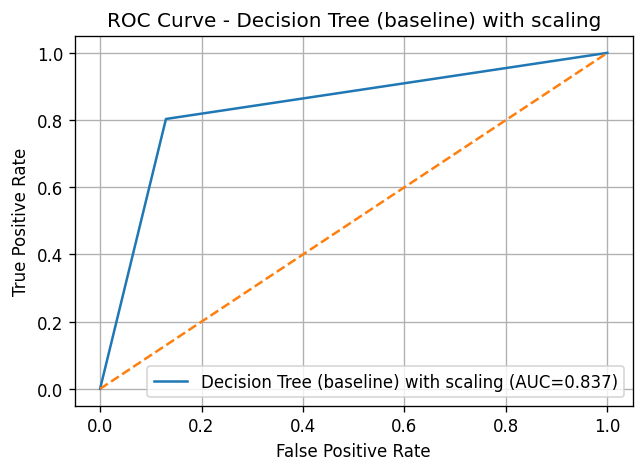


=== Decision Tree (baseline) without scaling ===
Accuracy: 0.8406
Confusion matrix:
 [[67 10]
 [12 49]]
              precision    recall  f1-score   support

           0      0.848     0.870     0.859        77
           1      0.831     0.803     0.817        61

    accuracy                          0.841       138
   macro avg      0.839     0.837     0.838       138
weighted avg      0.840     0.841     0.840       138

ROC–AUC: 0.8367


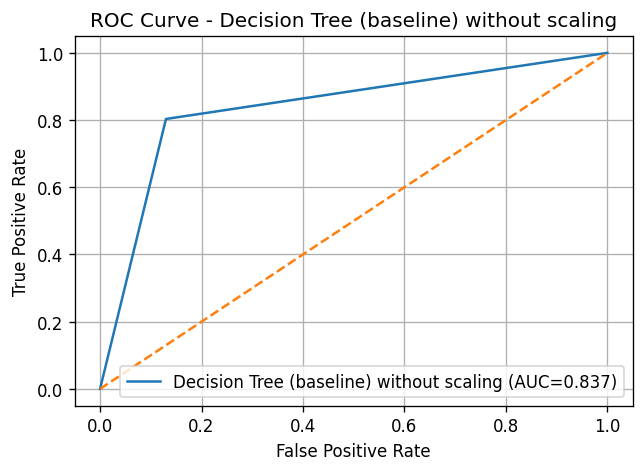


=== Random Forest (baseline) with scaling ===
Accuracy: 0.9058
Confusion matrix:
 [[72  5]
 [ 8 53]]
              precision    recall  f1-score   support

           0      0.900     0.935     0.917        77
           1      0.914     0.869     0.891        61

    accuracy                          0.906       138
   macro avg      0.907     0.902     0.904       138
weighted avg      0.906     0.906     0.906       138

ROC–AUC: 0.9631


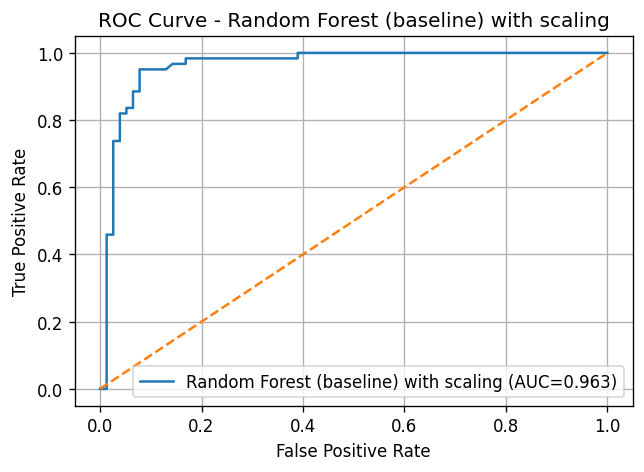


=== Random Forest (baseline) without scaling ===
Accuracy: 0.9058
Confusion matrix:
 [[72  5]
 [ 8 53]]
              precision    recall  f1-score   support

           0      0.900     0.935     0.917        77
           1      0.914     0.869     0.891        61

    accuracy                          0.906       138
   macro avg      0.907     0.902     0.904       138
weighted avg      0.906     0.906     0.906       138

ROC–AUC: 0.9627


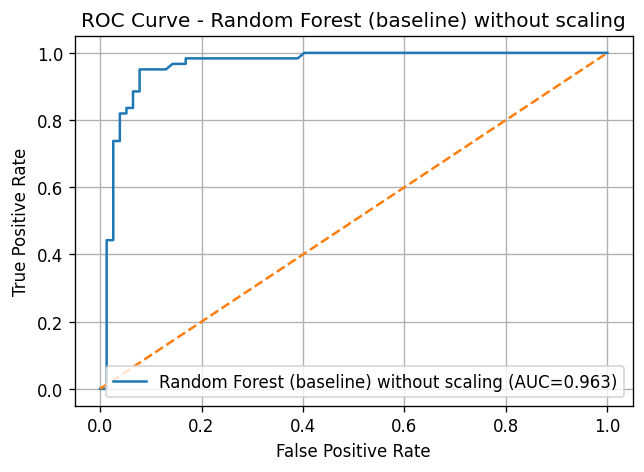


=== XGBoost (baseline) with scaling ===
Accuracy: 0.8768
Confusion matrix:
 [[70  7]
 [10 51]]
              precision    recall  f1-score   support

           0      0.875     0.909     0.892        77
           1      0.879     0.836     0.857        61

    accuracy                          0.877       138
   macro avg      0.877     0.873     0.874       138
weighted avg      0.877     0.877     0.876       138

ROC–AUC: 0.9555


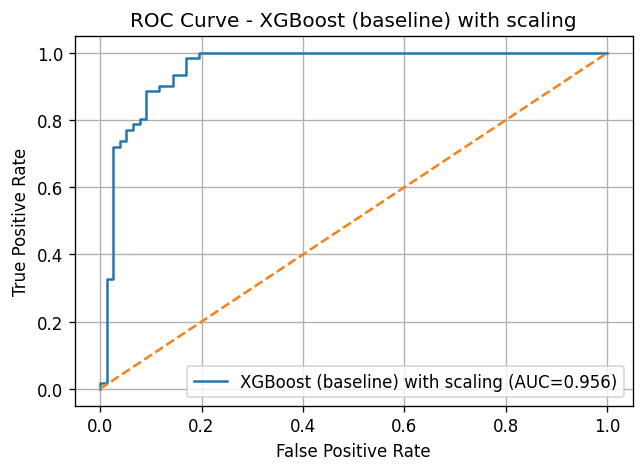


=== XGBoost (baseline) without scaling ===
Accuracy: 0.8768
Confusion matrix:
 [[70  7]
 [10 51]]
              precision    recall  f1-score   support

           0      0.875     0.909     0.892        77
           1      0.879     0.836     0.857        61

    accuracy                          0.877       138
   macro avg      0.877     0.873     0.874       138
weighted avg      0.877     0.877     0.876       138

ROC–AUC: 0.9555


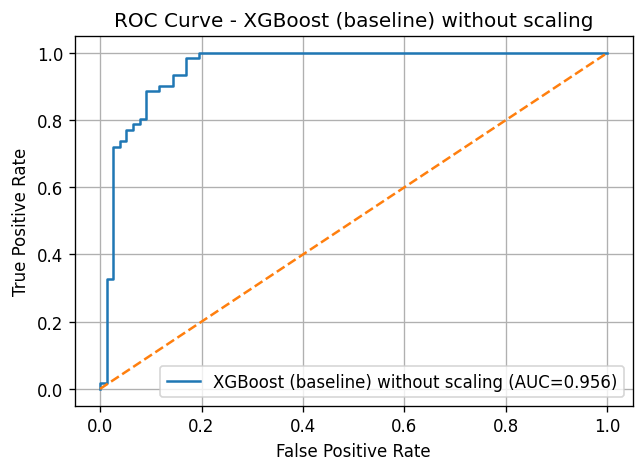

In [8]:
# Decision Tree
from re import L

# With scaling
dt_pipe_with_scaling = Pipeline(steps=[
    ("preproc", preprocessor_with_scaling),
    ("clf", DecisionTreeClassifier(random_state=42))
])
dt_pipe_with_scaling.fit(X_train, y_train)
evaluate_classifier("Decision Tree (baseline) with scaling", dt_pipe_with_scaling, X_train, y_train, X_test, y_test)

# Without scaling
dt_pipe_no_scaling = Pipeline(steps=[
    ("preproc", preprocessor_no_scaling),
    ("clf", DecisionTreeClassifier(random_state=42))
])
dt_pipe_no_scaling.fit(X_train, y_train)
evaluate_classifier("Decision Tree (baseline) without scaling", dt_pipe_no_scaling, X_train, y_train, X_test, y_test)

# Random Forest 
# With scaling
rf_pipe_with_scaling = Pipeline(steps=[
    ("preproc", preprocessor_with_scaling),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])
rf_pipe_with_scaling.fit(X_train, y_train)
evaluate_classifier("Random Forest (baseline) with scaling", rf_pipe_with_scaling, X_train, y_train, X_test, y_test)

# Without scaling
rf_pipe_no_scaling = Pipeline(steps=[
    ("preproc", preprocessor_no_scaling),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])
rf_pipe_no_scaling.fit(X_train, y_train)
evaluate_classifier("Random Forest (baseline) without scaling", rf_pipe_no_scaling, X_train, y_train, X_test, y_test)

# XGBoost
# With scaling
xgb_pipe_with_scaling = Pipeline(steps=[
    ("preproc", preprocessor_with_scaling),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False))
])
xgb_pipe_with_scaling.fit(X_train, y_train)
evaluate_classifier("XGBoost (baseline) with scaling", xgb_pipe_with_scaling, X_train, y_train, X_test, y_test)

# Without scaling
xgb_pipe_no_scaling = Pipeline(steps=[
    ("preproc", preprocessor_no_scaling),
    ("clf", XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False))
])
xgb_pipe_no_scaling.fit(X_train, y_train)
evaluate_classifier("XGBoost (baseline) without scaling", xgb_pipe_no_scaling, X_train, y_train, X_test, y_test)


## 5. Overfitting Analysis

We check **train vs test gap**, **learning curves**, and **tree depth vs accuracy**.


In [9]:
from sklearn.model_selection import learning_curve

# 1. Reporting overfit
def overfit_report(model_name, model, X_train, X_test, y_train, y_test):
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    gap = train_acc - test_acc
    print(f"\n📊 {model_name} Overfitting Check")
    print(f"Train Accuracy: {train_acc:.3f}")
    print(f"Test  Accuracy: {test_acc:.3f}")
    print(f"Gap (Train - Test): {gap:.3f}")
    if gap > 0.10:
        print("⚠️ Possible overfitting.")
    elif gap < -0.02:
        print("⚠️ Possible underfitting or data leakage.")
    else:
        print("✅ Good generalization balance.")

# Decision Tree overfitting with and without scaling        
overfit_report("Decision Tree with scaling", dt_pipe_with_scaling, X_train, X_test, y_train, y_test)
overfit_report("Decision Tree without scaling", dt_pipe_no_scaling, X_train, X_test, y_train, y_test)

# Random Forest overfitting with and without scaling
overfit_report("Random Forest with scaling", rf_pipe_with_scaling, X_train, X_test, y_train, y_test)
overfit_report("Random Forest without scaling", rf_pipe_no_scaling, X_train, X_test, y_train, y_test)

# XGBoost overfitting with and without scaling
overfit_report("XGBoost with scaling", xgb_pipe_with_scaling, X_train, X_test, y_train, y_test)
overfit_report("XGBoost without scaling", xgb_pipe_no_scaling, X_train, X_test, y_train, y_test)


📊 Decision Tree with scaling Overfitting Check
Train Accuracy: 1.000
Test  Accuracy: 0.841
Gap (Train - Test): 0.159
⚠️ Possible overfitting.

📊 Decision Tree without scaling Overfitting Check
Train Accuracy: 1.000
Test  Accuracy: 0.841
Gap (Train - Test): 0.159
⚠️ Possible overfitting.

📊 Random Forest with scaling Overfitting Check
Train Accuracy: 1.000
Test  Accuracy: 0.906
Gap (Train - Test): 0.094
✅ Good generalization balance.

📊 Random Forest without scaling Overfitting Check
Train Accuracy: 1.000
Test  Accuracy: 0.906
Gap (Train - Test): 0.094
✅ Good generalization balance.

📊 XGBoost with scaling Overfitting Check
Train Accuracy: 1.000
Test  Accuracy: 0.877
Gap (Train - Test): 0.123
⚠️ Possible overfitting.

📊 XGBoost without scaling Overfitting Check
Train Accuracy: 1.000
Test  Accuracy: 0.877
Gap (Train - Test): 0.123
⚠️ Possible overfitting.


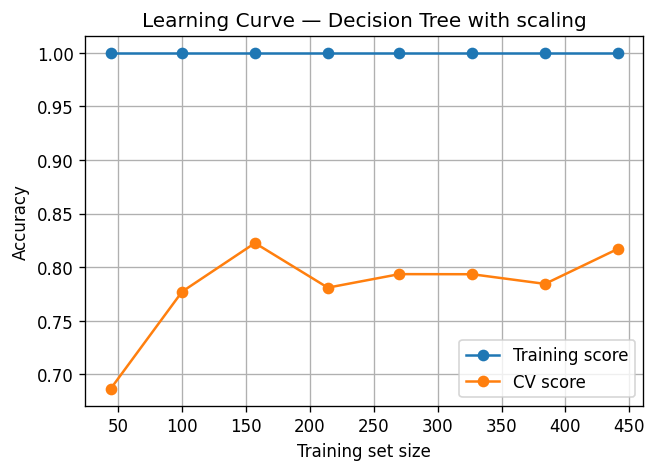

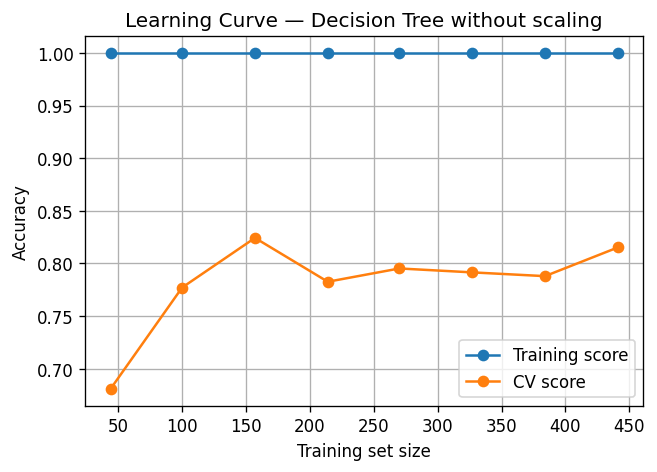

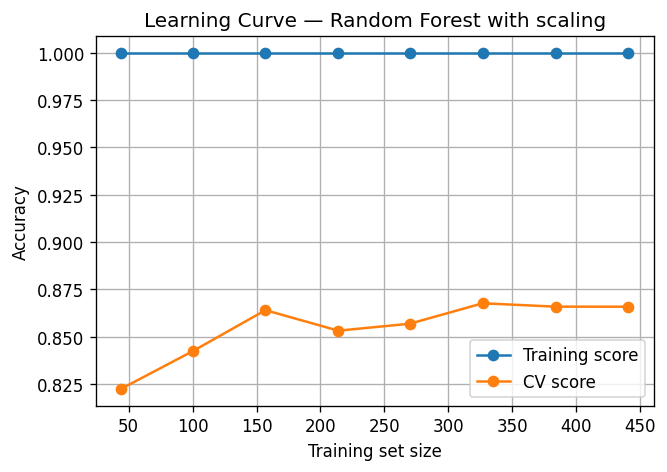

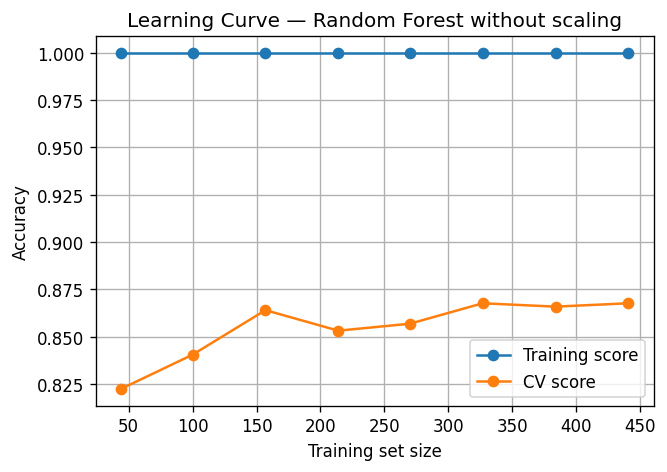

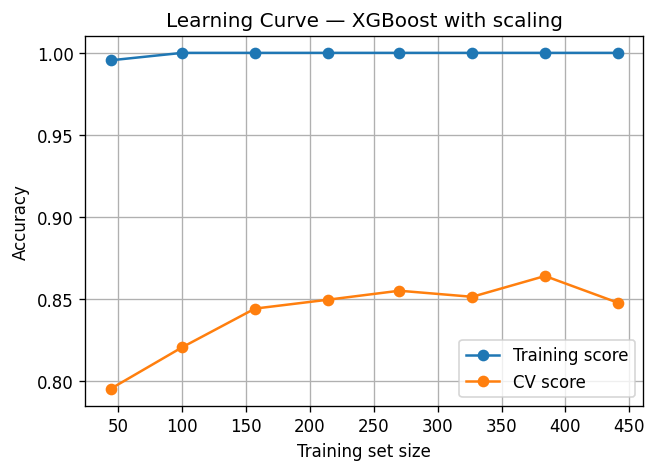

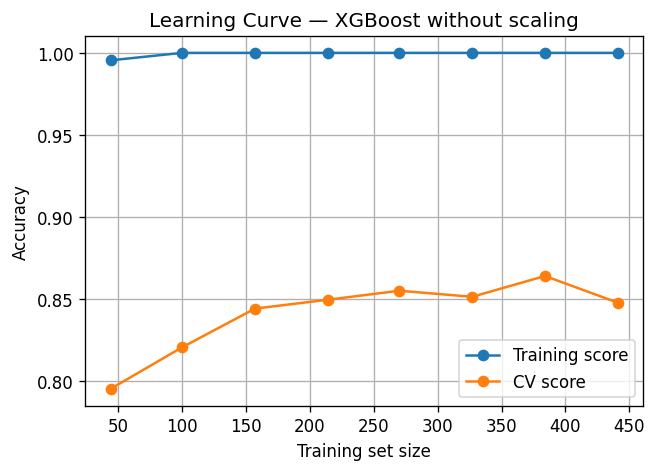

In [10]:
# 2. Learning curve (shows how a model’s performance changes as you increase the amount of training data)
def plot_learning_curve(title, estimator, X_train, y_train):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_train, y_train, cv=5, scoring="accuracy",
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 8), shuffle=True, random_state=42)
    train_mean = train_scores.mean(axis=1)
    test_mean  = test_scores.mean(axis=1)
    plt.figure()
    plt.plot(train_sizes, train_mean, 'o-', label="Training score")
    plt.plot(train_sizes, test_mean,  'o-', label="CV score")
    plt.xlabel("Training set size")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Decision Tree learning curve with and without scaling 
plot_learning_curve("Learning Curve — Decision Tree with scaling", dt_pipe_with_scaling, X_train, y_train)
plot_learning_curve("Learning Curve — Decision Tree without scaling", dt_pipe_no_scaling, X_train, y_train)

# Random Forest learning curve with and without scaling
plot_learning_curve("Learning Curve — Random Forest with scaling", rf_pipe_with_scaling, X_train, y_train)
plot_learning_curve("Learning Curve — Random Forest without scaling", rf_pipe_no_scaling, X_train, y_train)

# XGBoost learning curve with and without scaling   
plot_learning_curve("Learning Curve — XGBoost with scaling", xgb_pipe_with_scaling, X_train, y_train)
plot_learning_curve("Learning Curve — XGBoost without scaling", xgb_pipe_no_scaling, X_train, y_train)


In [ ]:
# 3. Decision Tree complexity (validation) curve: vary max_depth with and without scaling
depths_with_scaling = list(range(1, 16))
depths_without_scaling = list(range(1, 16))
train_accs_with_scaling, test_accs_with_scaling = [], []
train_accs_without_scaling, test_accs_without_scaling = [], []

# Populate for models with and without scaling
for d in depths_with_scaling:
    # Decision Tree with scaling
    model_with_scaling = Pipeline([("preproc", preprocessor_with_scaling), ("clf", DecisionTreeClassifier(max_depth=d, random_state=42))])
    model_with_scaling.fit(X_train, y_train)
    train_accs_with_scaling.append(accuracy_score(y_train, model_with_scaling.predict(X_train)))
    test_accs_with_scaling.append(accuracy_score(y_test,  model_with_scaling.predict(X_test)))

    # Decision Tree without scaling
    model_no_scaling = Pipeline([("preproc", preprocessor_no_scaling), ("clf", DecisionTreeClassifier(max_depth=d, random_state=42))])
    model_no_scaling.fit(X_train, y_train)
    train_accs_without_scaling.append(accuracy_score(y_train, model_no_scaling.predict(X_train)))
    test_accs_without_scaling.append(accuracy_score(y_test,  model_no_scaling.predict(X_test)))

# Plot for models with and without scaling
# Model with scaling
plt.figure()
plt.plot(depths_with_scaling, train_accs_with_scaling, 'o-', label="Train acc")
plt.plot(depths_with_scaling, test_accs_with_scaling,  'o-', label="Test acc")
plt.xlabel("Tree max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree with scaling: Depth vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Model without scaling
plt.figure()
plt.plot(depths_without_scaling, train_accs_without_scaling, 'o-', label="Train acc")
plt.plot(depths_without_scaling, test_accs_without_scaling,  'o-', label="Test acc")
plt.xlabel("Tree max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree without scaling: Depth vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()



> 🧩 **Think About It**  
> - Where does test accuracy peak? Does train–test gap widen with depth?  
> - What hyperparameters would you try to combat overfitting?


# 🧪 Student Exercises

## Exercise 1 — Scaling numerical features
In Section **2. Preprocessing pipeline**, we don't scale the numerical features.
1. [Done] Try re-running the code, but adding the scaling transformation.
2. How is the model performance now? Worse/Better?


## 6. Hyperparameter Tuning — Grid Search

We perform **5‑fold cross‑validation** inside the pipeline to avoid leakage. Metric: **ROC–AUC**.


In [ ]:
# Random Forest grid
param_grid_rf = {
    "clf__n_estimators": [200, 400, 800],
    "clf__max_depth": [None, 6, 10],
    "clf__min_samples_leaf": [1, 3, 5],
}
rf_grid = GridSearchCV(
    Pipeline([("preproc", preprocessor), ("clf", RandomForestClassifier(random_state=42))]),
    param_grid_rf, cv=5, scoring="roc_auc", n_jobs=-1, refit=True
)
rf_grid.fit(X_train, y_train)
print("RF best params:", rf_grid.best_params_)
print("RF best CV AUC:", rf_grid.best_score_)

# XGBoost grid
param_grid_xgb = {
    "clf__n_estimators": [100, 300, 600],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.03, 0.1, 0.2],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}
xgb_grid = GridSearchCV(
    Pipeline([("preproc", preprocessor),
              ("clf", XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False))]),
    param_grid_xgb, cv=5, scoring="roc_auc", n_jobs=-1, refit=True
)
xgb_grid.fit(X_train, y_train)
print("XGB best params:", xgb_grid.best_params_)
print("XGB best CV AUC:", xgb_grid.best_score_)


### 6.1 Baseline vs GridSearch (Test Set)


In [ ]:
# Compare baseline models: with vs without scaling
from sklearn.base import clone

models_config = [
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42)),
    ("XGBoost", XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False)),
]

results = []
roc_data = {}  # for plotting

for name, clf in models_config:
    for preproc, scaling_label in [(preprocessor_no_scaling, "No scaling"), (preprocessor_with_scaling, "With scaling")]:
        pipe = Pipeline([("preproc", preproc), ("clf", clone(clf))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        y_proba = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        results.append({"Model": name, "Scaling": scaling_label, "Accuracy": acc, "ROC-AUC": auc})
        roc_data[(name, scaling_label)] = roc_curve(y_test, y_proba)

# Comparison table
comp_df = pd.DataFrame(results)
print("=== Scaling comparison (Test Set) ===\n")
display(comp_df.pivot(index="Model", columns="Scaling", values=["Accuracy", "ROC-AUC"]).round(4))

# ROC curves (one subplot per model)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, _) in zip(axes, models_config):
    for scaling_label in ["No scaling", "With scaling"]:
        fpr, tpr, _ = roc_data[(name, scaling_label)]
        auc_val = comp_df[(comp_df["Model"] == name) & (comp_df["Scaling"] == scaling_label)]["ROC-AUC"].values[0]
        ax.plot(fpr, tpr, label=f"{scaling_label} (AUC={auc_val:.3f})")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(name)
    ax.legend(loc="lower right")
    ax.grid(True)
plt.suptitle("ROC Curves: Scaling vs No Scaling", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
def acc_auc(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = np.nan
    return acc, auc

rf_acc_b, rf_auc_b = acc_auc(rf_pipe, X_test, y_test)
rf_acc_g, rf_auc_g = acc_auc(rf_grid.best_estimator_, X_test, y_test)
xgb_acc_b, xgb_auc_b = acc_auc(xgb_pipe, X_test, y_test)
xgb_acc_g, xgb_auc_g = acc_auc(xgb_grid.best_estimator_, X_test, y_test)

print("Random Forest  — Base  ACC:{:.3f}  AUC:{:.3f} | Grid ACC:{:.3f}  AUC:{:.3f}".format(rf_acc_b, rf_auc_b, rf_acc_g, rf_auc_g))
print("XGBoost        — Base  ACC:{:.3f}  AUC:{:.3f} | Grid ACC:{:.3f}  AUC:{:.3f}".format(xgb_acc_b, xgb_auc_b, xgb_acc_g, xgb_auc_g))


### 6.2 Bayesian Optimization (Optuna)

**Why?** It can find strong configurations with fewer evaluations than exhaustive grids.


In [ ]:
import optuna
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric': 'logloss',
        'random_state': 42,
        'use_label_encoder': False,
        'n_jobs': -1,
    }
    pipe = Pipeline([('preproc', preprocessor), ('clf', XGBClassifier(**params))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Get the best-performing hyperparameter set
study = optuna.create_study(direction='maximize', study_name='xgb_credit_auc')
study.optimize(objective_xgb, n_trials=30, show_progress_bar=False)
print("Best XGB CV AUC:", study.best_value)
print("Best XGB params:", study.best_params)

# Train the final tuned model on all training data
best_xgb_pipe = Pipeline([('preproc', preprocessor), ('clf', XGBClassifier(**{**study.best_params, 'eval_metric':'logloss', 'random_state':42, 'use_label_encoder':False, 'n_jobs':-1}))])
best_xgb_pipe.fit(X_train, y_train)
y_pred = best_xgb_pipe.predict(X_test)
y_proba = best_xgb_pipe.predict_proba(X_test)[:, 1]
print("Optuna XGB — Test ACC:", accuracy_score(y_test, y_pred))
print("Optuna XGB — Test AUC:", roc_auc_score(y_test, y_proba))


### 6.3 Optuna for Random Forest


In [ ]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_categorical('max_depth', [None, 4, 6, 8, 10, 12]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1,
    }
    pipe = Pipeline([('preproc', preprocessor), ('clf', RandomForestClassifier(**params))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Get the best-performing hyperparameter set
rf_study = optuna.create_study(direction='maximize', study_name='rf_credit_auc')
rf_study.optimize(objective_rf, n_trials=30, show_progress_bar=False)
print("Best RF CV AUC:", rf_study.best_value)
print("Best RF params:", rf_study.best_params)

# Train the final tuned model on all training data
best_rf_pipe = Pipeline([('preproc', preprocessor), ('clf', RandomForestClassifier(**{**rf_study.best_params, 'random_state':42, 'n_jobs':-1}))])
best_rf_pipe.fit(X_train, y_train)
y_pred = best_rf_pipe.predict(X_test)
y_proba = best_rf_pipe.predict_proba(X_test)[:, 1]
print("Optuna RF — Test ACC:", accuracy_score(y_test, y_pred))
print("Optuna RF — Test AUC:", roc_auc_score(y_test, y_proba))

### 6.4 Comparison Table — Baseline vs Grid vs Optuna

In [ ]:
def acc_auc_of(pipe):
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    return acc, auc

rows = []
rows.append(["RandomForest", "Baseline"] + list(acc_auc_of(rf_pipe)))
rows.append(["RandomForest", "GridSearch"] + list(acc_auc_of(rf_grid.best_estimator_)))
rows.append(["RandomForest", "Optuna"] + list(acc_auc_of(best_rf_pipe)))
rows.append(["XGBoost", "Baseline"] + list(acc_auc_of(xgb_pipe)))
rows.append(["XGBoost", "GridSearch"] + list(acc_auc_of(xgb_grid.best_estimator_)))
rows.append(["XGBoost", "Optuna"] + list(acc_auc_of(best_xgb_pipe)))

results_df = pd.DataFrame(rows, columns=["Model", "Method", "Test_Accuracy", "Test_ROC_AUC"])
results_df


## 7. Precision–Recall, Calibration & Threshold Tuning


In [ ]:
# Plot Precision-Recall curve and calculate the Average Precision (area under the PR curve; the higher, the better) score for multiple models
def plot_pr(models_dict):
    plt.figure()
    aps = {}
    for name, mdl in models_dict.items():
        proba = mdl.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, proba)
        ap = average_precision_score(y_test, proba)
        aps[name] = ap
        plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall Curves (Test)")
    plt.legend()
    plt.grid(True)
    plt.show()
    return aps

models_for_pr = {
    "RF Grid": rf_grid.best_estimator_,
    "RF Optuna": best_rf_pipe,
    "XGB Grid": xgb_grid.best_estimator_,
    "XGB Optuna": best_xgb_pipe,
}
aps = plot_pr(models_for_pr)
print("Average Precision:", aps)

In [ ]:
# ?calibration_curve

In [ ]:
# Plot Calibration Curve
# Model calibration techniques are used to adjust the predicted probabilities of a classification model so that they better reflect the true likelihood of an event.
# Techniques: Platt Scaling, Isotonic Regression, Temperature Scaling, Beta Calibration, Histogram Binning.
# Above the diagonal → model is under-confident (predicted probs are too low).
# Below the diagonal → model is over-confident (predicted probs are too high).
# On the diagonal → well calibrated.
# In practice:
    # Logistic Regression is usually well-calibrated by default.
    # Ensemble models (Random Forest, XGBoost) tend to be overconfident, and neural networks often underconfident.

def plot_calibration(models_dict):
    plt.figure()
    for name, mdl in models_dict.items():
        proba = mdl.predict_proba(X_test)[:, 1]
        frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')   # Create 10 bins with (roughly) equal numbers of samples (good choice for imbalanced data).
        plt.plot(mean_pred, frac_pos, marker='o', label=name)
    plt.plot([0,1],[0,1], linestyle='--')                                                        # Perfect calibration reference
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title('Calibration (Reliability) Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_calibration(models_for_pr)

# Brier scores: mean squared error between predicted probs and outcomes (Lower = better overall probability quality).
print("Brier scores:")
for name, mdl in models_for_pr.items():
    proba = mdl.predict_proba(X_test)[:, 1]
    print(f"  {name}: {brier_score_loss(y_test, proba):.4f}")


In [ ]:
# Threshold tuning (maximize F1) for the best XGBoost (Optuna)
# F1=2×Precision×Recall/(Precision+Recall)

proba = best_xgb_pipe.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0, 1, 201)
from sklearn.metrics import f1_score, precision_score, recall_score

f1s, precs, recs = [], [], []
for t in thresholds:
    yhat = (proba >= t).astype(int)                                     # Convert probabilities to predicted classes.
    f1s.append(f1_score(y_test, yhat))          
    precs.append(precision_score(y_test, yhat, zero_division=0))        # zero_division=0 avoids division errors when no positives are predicted. 
    recs.append(recall_score(y_test, yhat))

plt.figure()
plt.plot(thresholds, f1s, label="F1")
plt.plot(thresholds, precs, label="Precision")
plt.plot(thresholds, recs, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning — XGB (Optuna)")
plt.legend()
plt.grid(True)
plt.show()

best_t = thresholds[int(np.argmax(f1s))]                                # np.argmax(f1s) gives the index of the maximum F1 score.
print("Best threshold by F1:", best_t)                                  # The intersection or peak of F1 often occurs where precision and recall curves intersect.

# The chosen threshold is where your model’s predicted probabilities best balance false positives and false negatives according to the F1 metric.


> 🧩 **Think About It**  
> - How does the **optimal threshold** change the number of approvals/denials?  
> - If false approvals are more costly than false denials, how would you choose a threshold?



## 8. Interpretability — SHAP & LIME (XGBoost)

We explain predictions **after encoding** (post‑OneHot) to match the model's inputs.


In [ ]:
import shap
from lime.lime_tabular import LimeTabularExplainer

# Transform features after preprocessing to get encoded names (builds human-readable encoded names)
preproc = xgb_pipe.named_steps["preproc"]
def get_feature_names(preprocessor, numeric_features, categorical_features):
    cat_ohe = preprocessor.named_transformers_["cat"].named_steps["encoder"]
    cat_names = list(cat_ohe.get_feature_names_out(categorical_features))
    return numeric_features + cat_names

feature_names_enc = get_feature_names(preproc, num_feats, cat_feats)
X_train_enc = preproc.transform(X_train)
X_test_enc  = preproc.transform(X_test)
if hasattr(X_train_enc, "toarray"):
    X_train_enc = X_train_enc.toarray()
    X_test_enc = X_test_enc.toarray()

In [ ]:
# SHAP: game-theoretic, consistent, additive; great for global patterns and also has local force plots. More stable, but can be heavier.
shap.initjs()
xgb_clf = best_xgb_pipe.named_steps["clf"]
explainer = shap.TreeExplainer(xgb_clf)
X_sample = X_train_enc  # subset if slow
sv = explainer(X_sample)
shap.summary_plot(sv.values, X_sample, feature_names=feature_names_enc, show=True)
# shap.plots.bar(sv, max_display=20, show=True)

In [ ]:
# LIME: fast, intuitive local linear surrogate; great for case-by-case storytelling; less stable and depends on local sampling kernel.
# LIME builds a local weighted linear model around the selected point X_test_enc[idx] using your model’s predict_proba.

lime_explainer = LimeTabularExplainer(
    training_data=X_train_enc, feature_names=feature_names_enc,
    class_names=["Not approved", "Approved"], discretize_continuous=False, mode="classification"
)
idx = 0  # change index to inspect other cases
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_enc[idx], predict_fn=xgb_clf.predict_proba, num_features=12
)
print("LIME local explanation (top contributions):")
for t in lime_exp.as_list():
    print(t)
fig = lime_exp.as_pyplot_figure()
fig.suptitle("LIME explanation — XGB (Optuna)", y=1.03)
plt.tight_layout(); plt.show()